In [260]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [262]:
profile_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv"
profile_df = pd.read_csv(profile_genre_url)

In [263]:
test_users_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
test_users_df = pd.read_csv(test_users_url)

In [264]:
course_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv"
course_genres_df = pd.read_csv(course_genre_url)

# EDA Process

### Course Counts per Genre 

/var/folders/qh/6yqnnssd70l9bv41njc6xpcc0000gn/T/ipykernel_1982/2376666626.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values,y=genre_counts.index,palette='coolwarm')


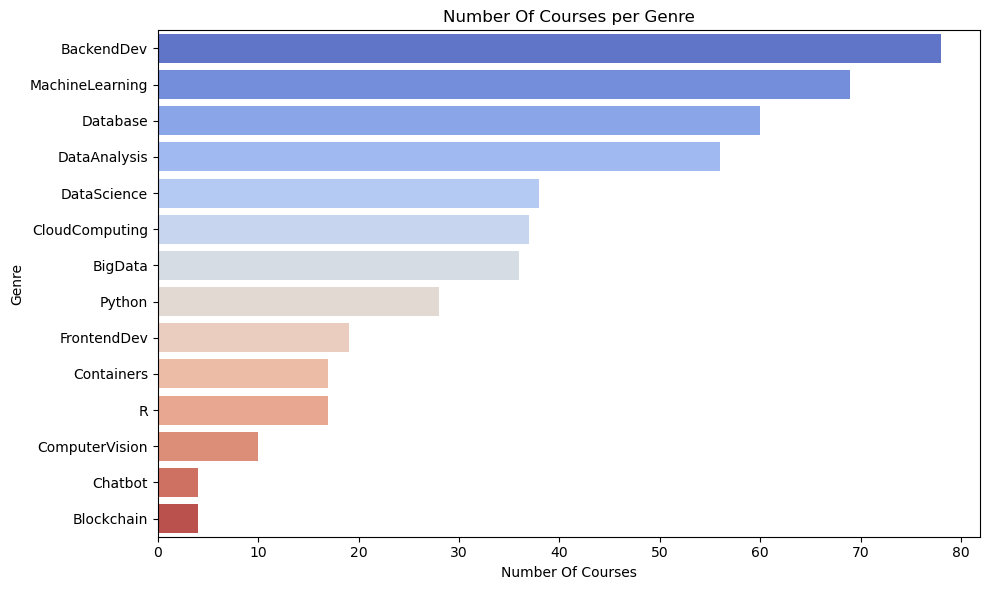

In [267]:
genre_counts = course_genres_df.drop(['COURSE_ID','TITLE'],axis=1).sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values,y=genre_counts.index,palette='coolwarm')
plt.title("Number Of Courses per Genre")
plt.xlabel("Number Of Courses")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Course Enrollment Distribution 

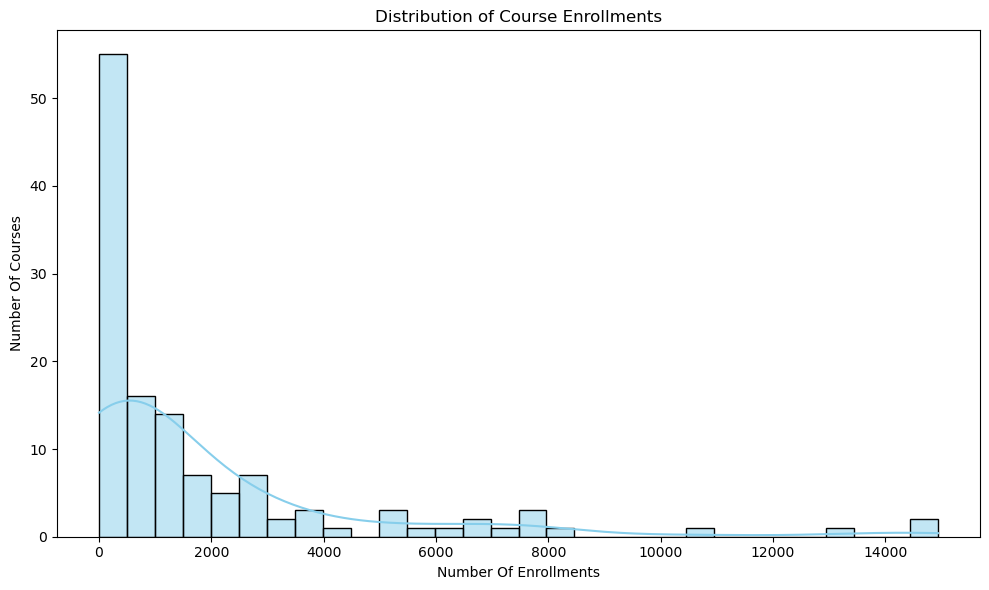

In [269]:
enrollments_per_course = test_users_df['item'].value_counts()
plt.figure(figsize=(10,6))
sns.histplot(enrollments_per_course,bins=30,color='skyblue',kde=True)
plt.title("Distribution of Course Enrollments")
plt.xlabel("Number Of Enrollments")
plt.ylabel("Number Of Courses")
plt.tight_layout()
plt.show()

### Top 20 Most Popular Courses

/var/folders/qh/6yqnnssd70l9bv41njc6xpcc0000gn/T/ipykernel_1982/1231996827.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='TITLE', x='Enrollments',data = popular_courses,palette='viridis')


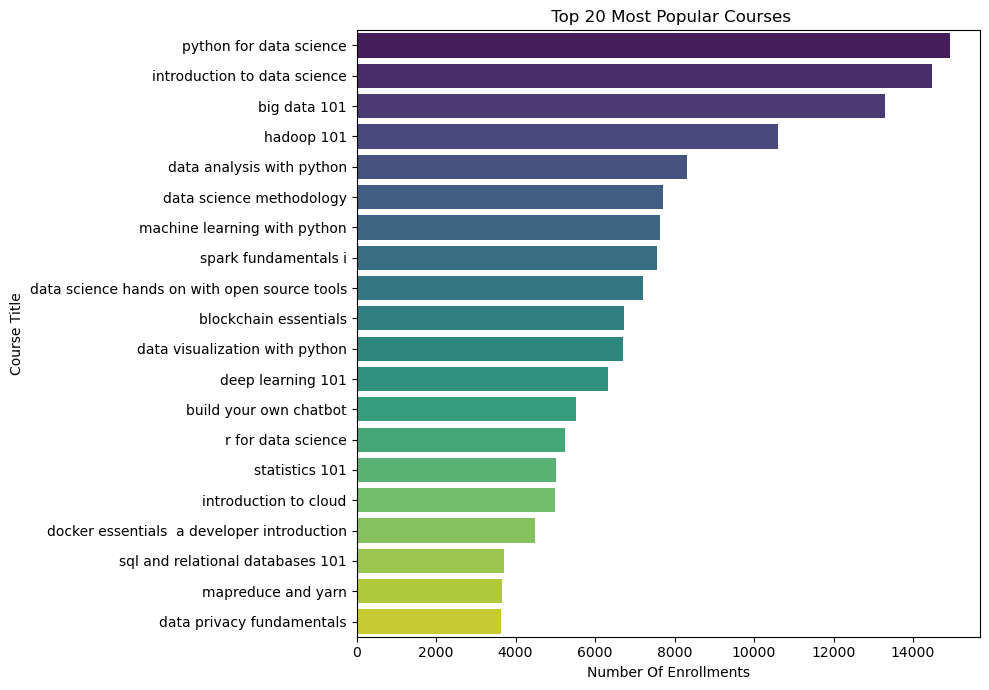

In [271]:
popular_courses = test_users_df['item'].value_counts().head(20).reset_index()
popular_courses.columns = ["COURSE_ID","Enrollments"]
popular_courses = popular_courses.merge(course_genres_df[['COURSE_ID','TITLE']],on='COURSE_ID',how='left')

plt.figure(figsize=(10,7))
sns.barplot(y='TITLE', x='Enrollments',data = popular_courses,palette='viridis')
plt.title(" Top 20 Most Popular Courses")
plt.xlabel("Number Of Enrollments")
plt.ylabel("Course Title")
plt.tight_layout()
plt.show()

                                        

### Word Cloud of Course Titles

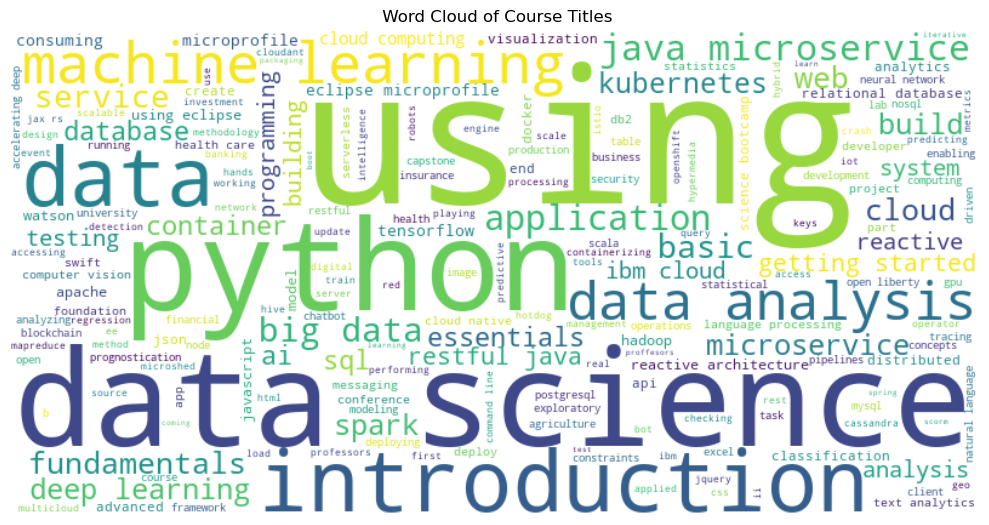

In [273]:
from wordcloud import WordCloud
text = ' '.join(course_genres_df['TITLE'])

wordcloud = WordCloud(width=800,height=400,background_color='white').generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title(" Word Cloud of Course Titles")
plt.tight_layout()
plt.show()

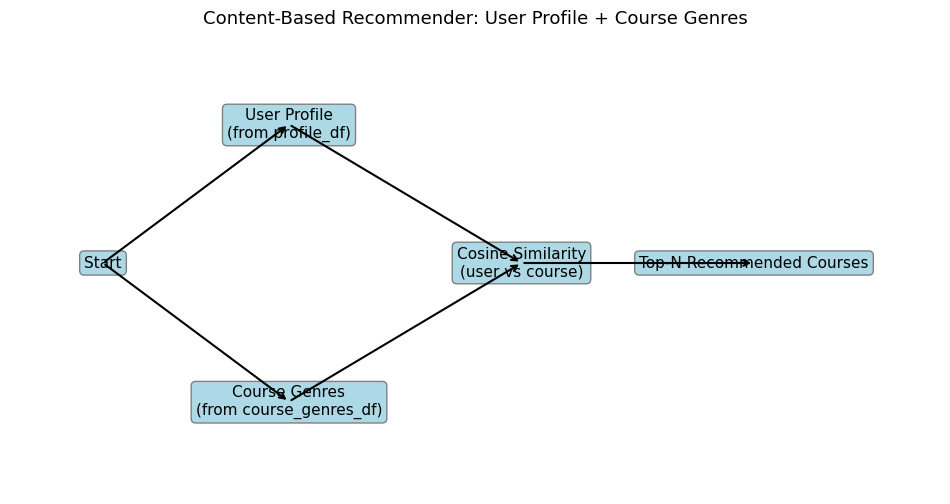

In [181]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_flowchart_user_profile():
    fig, ax = plt.subplots(figsize=(12, 6))

    # Boxes
    boxes = {
        "Start": (0.1, 0.5),
        "User Profile\n(from profile_df)": (0.3, 0.8),
        "Course Genres\n(from course_genres_df)": (0.3, 0.2),
        "Cosine Similarity\n(user vs course)": (0.55, 0.5),
        "Top-N Recommended Courses": (0.8, 0.5)
    }

    for text, (x, y) in boxes.items():
        ax.text(x, y, text, ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="gray"))

    # Arrows
    arrows = [
        ("Start", "User Profile\n(from profile_df)"),
        ("Start", "Course Genres\n(from course_genres_df)"),
        ("User Profile\n(from profile_df)", "Cosine Similarity\n(user vs course)"),
        ("Course Genres\n(from course_genres_df)", "Cosine Similarity\n(user vs course)"),
        ("Cosine Similarity\n(user vs course)", "Top-N Recommended Courses")
    ]

    for start, end in arrows:
        x1, y1 = boxes[start]
        x2, y2 = boxes[end]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color='black'))

    ax.axis('off')
    plt.title("Content-Based Recommender: User Profile + Course Genres", fontsize=13)
    plt.show()

draw_flowchart_user_profile()


Results for different values of top_n:
top_n = 3: Average unseen recommendations = 2.47
top_n = 5: Average unseen recommendations = 4.18
top_n = 7: Average unseen recommendations = 5.90
top_n = 10: Average unseen recommendations = 8.52


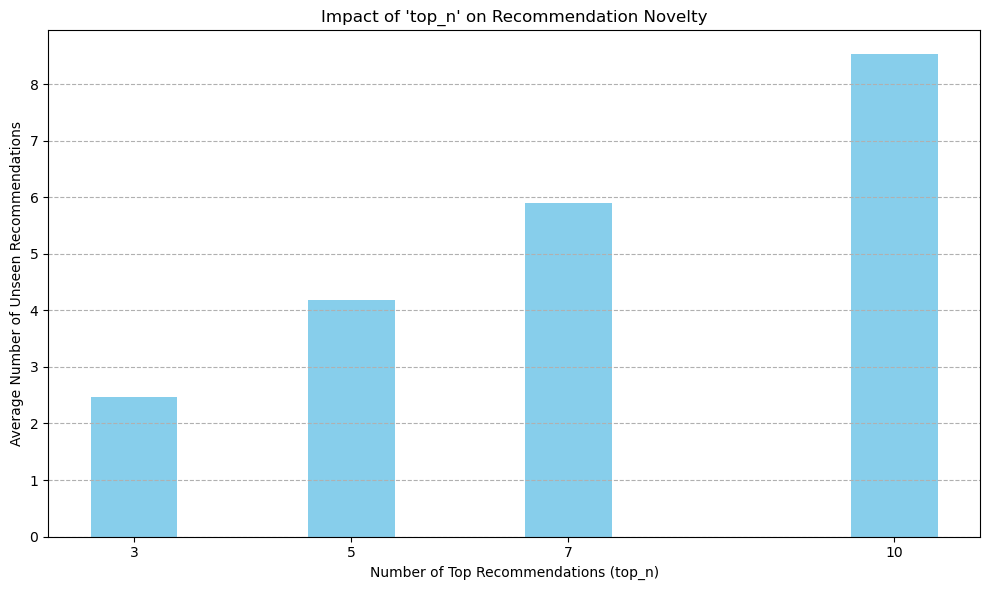

In [308]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Assume course_genres_df, profile_df, and test_users_df are already loaded

genre_cols = course_genres_df.columns[2:]
user_profiles = profile_df[genre_cols].fillna(0).values
course_features = course_genres_df[genre_cols].fillna(0).values

similarity_matrix = cosine_similarity(user_profiles, course_features)

# Hyperparameter: Number of top recommendations (top_n)
top_n_values = [3, 5, 7, 10]
results = {}

for top_n in top_n_values:
    recommendations = {}
    for user_index in range(user_profiles.shape[0]):
        user_id = profile_df.iloc[user_index]['user']
        top_indices = similarity_matrix[user_index].argsort()[::-1][:top_n]
        top_courses = course_genres_df.iloc[top_indices]['COURSE_ID'].tolist()
        recommendations[user_id] = top_courses

    seen_courses = test_users_df.groupby('user')['item'].apply(set).to_dict()
    unseen_counts = []
    for user_id, recs in recommendations.items():
        seen = seen_courses.get(user_id, set())
        new_courses = [course for course in recs if course not in seen]
        unseen_counts.append(len(new_courses))

    if unseen_counts:
        avg_unseen = np.mean(unseen_counts)
    else:
        avg_unseen = 0
    results[top_n] = avg_unseen

print("Results for different values of top_n:")
for k, v in results.items():
    print(f"top_n = {k}: Average unseen recommendations = {v:.2f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.xlabel("Number of Top Recommendations (top_n)")
plt.ylabel("Average Number of Unseen Recommendations")
plt.title("Impact of 'top_n' on Recommendation Novelty")
plt.xticks(list(results.keys()))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [310]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from collections import Counter

genre_cols = course_genres_df.columns[2:]
user_profiles = profile_df[genre_cols].fillna(0).values
course_features = course_genres_df[genre_cols].fillna(0).values

similarity_matrix = cosine_similarity(user_profiles, course_features)

top_n = 5
recommendations = {}

for user_index in range(user_profiles.shape[0]):
    user_id = profile_df.iloc[user_index]['user']
    top_indices = similarity_matrix[user_index].argsort()[::-1][:top_n]
    top_courses = course_genres_df.iloc[top_indices]['COURSE_ID'].tolist()
    recommendations[user_id] = top_courses

print("Sample recommendations:")
for k, v in list(recommendations.items())[:5]:
    print(k, v)

seen_courses = test_users_df.groupby('user')['item'].apply(set).to_dict()

unseen_counts = []
for user_id, recs in recommendations.items():
    seen = seen_courses.get(user_id, set())
    new_courses = [course for course in recs if course not in seen]
    unseen_counts.append(len(new_courses))

if unseen_counts:
    avg_unseen = np.mean(unseen_counts)
    print(f"Average unseen courses recommended: {avg_unseen:.2f}")
else:
    print("No unseen recommendations could be computed.")

all_recs = [course for recs in recommendations.values() for course in recs]
top_10_courses = Counter(all_recs).most_common(10)
print("Top 10 Recommended Courses:\n", top_10_courses)


Sample recommendations:
2.0 ['excourse72', 'BD0211EN', 'SC0103EN', 'TMP0105EN', 'BD0212EN']
4.0 ['BD0211EN', 'SC0103EN', 'BD0212EN', 'TMP0105EN', 'excourse72']
5.0 ['GPXX0IBEN', 'SW0201EN', 'SW0101EN', 'TMP0101EN', 'excourse54']
7.0 ['excourse72', 'excourse73', 'BD0211EN', 'TMP0105EN', 'BD0212EN']
8.0 ['TMP0105EN', 'BD0212EN', 'excourse72', 'excourse73', 'BD0211EN']
Average unseen courses recommended: 4.18
Top 10 Recommended Courses:
 [('ML0122EN', 4468), ('excourse22', 4197), ('excourse21', 4136), ('ML0101EN', 4131), ('TMP0105EN', 3369), ('excourse72', 3329), ('BD0212EN', 3283), ('BD0211EN', 3196), ('CC0121EN', 3155), ('excourse73', 3133)]


In [312]:
# Map user -> seen courses
seen_courses = test_users_df.groupby('user')['item'].apply(set).to_dict()

unseen_counts = []
for user_id, recs in recommendations.items():
    seen = seen_courses.get(user_id, set())
    new_courses = [course for course in recs if course not in seen]
    unseen_counts.append(len(new_courses))

avg_unseen = np.mean(unseen_counts)
print(f"Average unseen courses recommended: {avg_unseen:.2f}")


Average unseen courses recommended: 4.18


In [314]:
from collections import Counter

all_recs = [course for recs in recommendations.values() for course in recs]
top_10_courses = Counter(all_recs).most_common(10)
print("Top 10 Recommended Courses:\n", top_10_courses)


Top 10 Recommended Courses:
 [('ML0122EN', 4468), ('excourse22', 4197), ('excourse21', 4136), ('ML0101EN', 4131), ('TMP0105EN', 3369), ('excourse72', 3329), ('BD0212EN', 3283), ('BD0211EN', 3196), ('CC0121EN', 3155), ('excourse73', 3133)]


In [316]:
pd.DataFrame(top_10_courses,columns=['Course_Id','No of Rec.'])

,Course_Id,No of Rec.
0,ML0122EN,4468
1,excourse22,4197
2,excourse21,4136
3,ML0101EN,4131
4,TMP0105EN,3369
5,excourse72,3329
6,BD0212EN,3283
7,BD0211EN,3196
8,CC0121EN,3155
9,excourse73,3133


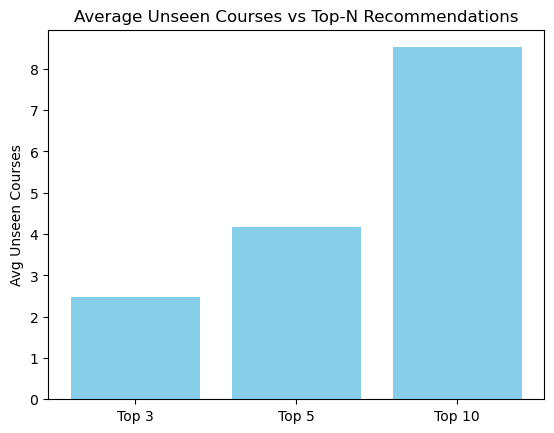

In [244]:
import matplotlib.pyplot as plt

results = {}
for top_n in [3, 5, 10]:
    temp_recs = {}
    for user_index in range(user_profiles.shape[0]):
        user_id = profile_df.iloc[user_index]['user']
        top_indices = similarity_matrix[user_index].argsort()[::-1][:top_n]
        top_courses = course_genres_df.iloc[top_indices]['COURSE_ID'].tolist()
        temp_recs[user_id] = top_courses

    unseen_counts = []
    for user_id, recs in temp_recs.items():
        seen = seen_courses.get(user_id, set())
        new_courses = [course for course in recs if course not in seen]
        unseen_counts.append(len(new_courses))
    results[f"Top {top_n}"] = np.mean(unseen_counts)

# Plot
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title("Average Unseen Courses vs Top-N Recommendations")
plt.ylabel("Avg Unseen Courses")
plt.show()


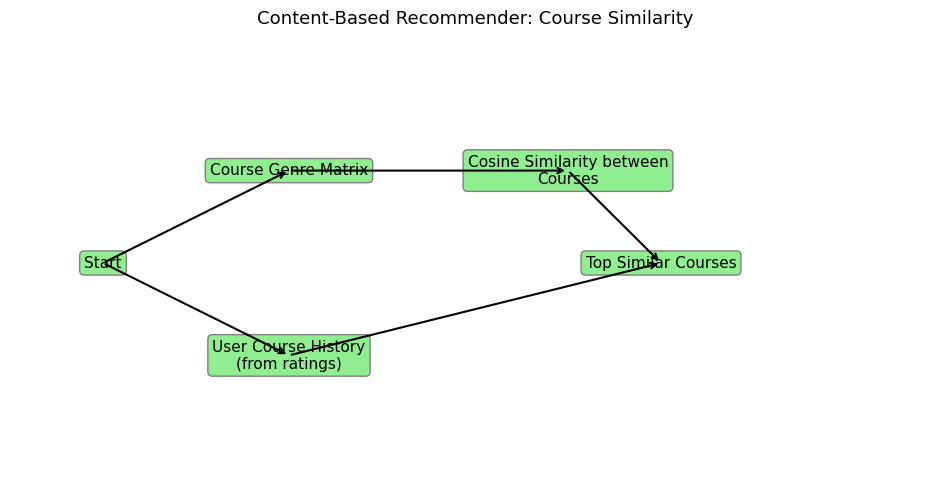

In [250]:
def draw_flowchart_course_similarity():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    boxes = {
        "Start": (0.1, 0.5),
        "Course Genre Matrix": (0.3, 0.7),
        "Cosine Similarity between\nCourses": (0.6, 0.7),
        "User Course History\n(from ratings)": (0.3, 0.3),
        "Top Similar Courses": (0.7, 0.5)
    }

    for text, (x, y) in boxes.items():
        ax.text(x, y, text, ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", edgecolor="gray"))

    arrows = [
        ("Start", "Course Genre Matrix"),
        ("Start", "User Course History\n(from ratings)"),
        ("Course Genre Matrix", "Cosine Similarity between\nCourses"),
        ("User Course History\n(from ratings)", "Top Similar Courses"),
        ("Cosine Similarity between\nCourses", "Top Similar Courses")
    ]

    for start, end in arrows:
        x1, y1 = boxes[start]
        x2, y2 = boxes[end]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color='black'))

    ax.axis('off')
    plt.title("Content-Based Recommender: Course Similarity", fontsize=13)
    plt.show()

draw_flowchart_course_similarity()


In [252]:
# Build course-course similarity matrix
course_features = course_genres_df[genre_cols].values
course_sim_matrix = cosine_similarity(course_features)

course_id_to_idx = {cid: idx for idx, cid in enumerate(course_genres_df['COURSE_ID'])}
idx_to_course_id = {idx: cid for cid, idx in course_id_to_idx.items()}

similarity_recs = {}

for user_id, group in test_users_df.groupby('user'):
    seen = group['item'].tolist()
    sim_scores = np.zeros(len(course_genres_df))
    
    for course in seen:
        idx = course_id_to_idx.get(course)
        if idx is not None:
            sim_scores += course_sim_matrix[idx]

    # Remove already seen
    for course in seen:
        idx = course_id_to_idx.get(course)
        if idx is not None:
            sim_scores[idx] = 0
            
    top_indices = sim_scores.argsort()[::-1][:5]
    recommended = [idx_to_course_id[i] for i in top_indices]
    similarity_recs[user_id] = recommended


In [254]:
similarity_recs

{2: ['excourse73', 'excourse72', 'excourse02', 'BD0115EN', 'GPXX097UEN'],
 4: ['excourse73', 'excourse72', 'excourse02', 'excourse04', 'excourse06'],
 5: ['SW0201EN', 'SW0101EN', 'GPXX0IBEN', 'excourse54', 'excourse40'],
 7: ['excourse72', 'excourse73', 'TMP0105EN', 'BD0212EN', 'SC0103EN'],
 8: ['BD0211EN', 'SC0103EN', 'TMP0105EN', 'excourse72', 'excourse73'],
 9: ['GPXX0M6UEN', 'GPXX097UEN', 'excourse70', 'excourse71', 'BD0145EN'],
 12: ['SC0103EN', 'excourse72', 'excourse73', 'GPXX0IBEN', 'BD0223EN'],
 16: ['TA0106EN', 'SC0103EN', 'TMP0105EN', 'excourse72', 'excourse73'],
 17: ['GPXX048OEN', 'BENTEST4', 'ML0111EN', 'excourse47', 'HCC105EN'],
 19: ['BD0111EN', 'BD0115EN', 'GPXX097UEN', 'DB0151EN', 'BD0141EN'],
 20: ['excourse52', 'excourse77', 'GPXX0UN5EN', 'excourse60', 'ML0120ENv3'],
 21: ['excourse03', 'BD0115EN', 'excourse42', 'excourse71', 'excourse70'],
 22: ['ML0151EN', 'DX0106EN', 'RP0101EN', 'ML0101EN', 'excourse21'],
 23: ['GPXX0IBEN', 'SC0103EN', 'excourse72', 'excourse73',

In [256]:
# Unseen count
unseen_counts = []
for user_id, recs in similarity_recs.items():
    seen = seen_courses.get(user_id, set())
    new_courses = [course for course in recs if course not in seen]
    unseen_counts.append(len(new_courses))

print("Avg unseen recommendations:", np.mean(unseen_counts))

# Top 10 courses
from collections import Counter
top_10 = Counter([c for r in similarity_recs.values() for c in r]).most_common(10)
print("Top 10 Recommended (Course Similarity):", top_10)


Avg unseen recommendations: 5.0
Top 10 Recommended (Course Similarity): [('ML0122EN', 4555), ('excourse22', 4384), ('excourse21', 4272), ('ML0101EN', 3747), ('excourse72', 3134), ('excourse73', 2993), ('TMP0105EN', 2862), ('excourse63', 2658), ('excourse64', 2635), ('excourse06', 2533)]


In [318]:
pd.DataFrame(top_10,columns=['Course_Id','No of Rec.'])

,Course_Id,No of Rec.
0,ML0122EN,4555
1,excourse22,4384
2,excourse21,4272
3,ML0101EN,3747
4,excourse72,3134
5,excourse73,2993
6,TMP0105EN,2862
7,excourse63,2658
8,excourse64,2635
9,excourse06,2533


Results for different values of top_n (Course Similarity):
top_n = 3: Average unseen recommendations = 3.00
top_n = 5: Average unseen recommendations = 5.00
top_n = 7: Average unseen recommendations = 7.00
top_n = 10: Average unseen recommendations = 10.00


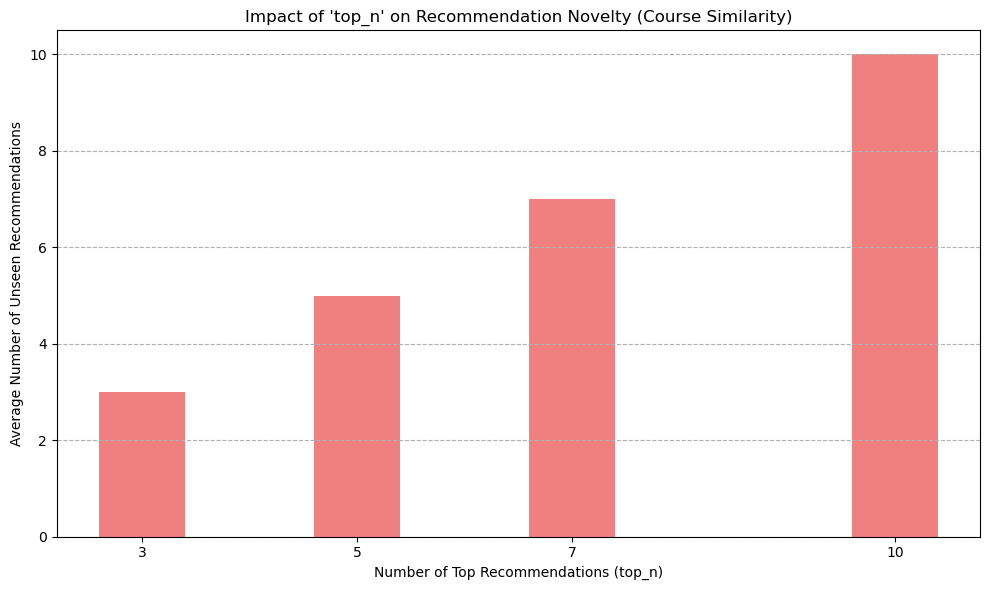

In [320]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Assume course_genres_df, profile_df, and test_users_df are already loaded

genre_cols = course_genres_df.columns[2:]
user_profiles = profile_df[genre_cols].fillna(0).values
course_features = course_genres_df[genre_cols].fillna(0).values

course_sim_matrix = cosine_similarity(course_features)
course_id_to_idx = {cid: idx for idx, cid in enumerate(course_genres_df['COURSE_ID'])}
idx_to_course_id = {idx: cid for cid, idx in course_id_to_idx.items()}

# Hyperparameter: Number of top recommendations (top_n)
top_n_values = [3, 5, 7, 10]
results = {}

for top_n in top_n_values:
    similarity_recs = {}
    for user_id, group in test_users_df.groupby('user'):
        seen = group['item'].tolist()
        sim_scores = np.zeros(len(course_genres_df))

        for course in seen:
            idx = course_id_to_idx.get(course)
            if idx is not None:
                sim_scores += course_sim_matrix[idx]

        # Remove already seen
        for course in seen:
            idx = course_id_to_idx.get(course)
            if idx is not None:
                sim_scores[idx] = 0

        top_indices = sim_scores.argsort()[::-1][:top_n]
        recommended = [idx_to_course_id[i] for i in top_indices]
        similarity_recs[user_id] = recommended

    seen_courses = test_users_df.groupby('user')['item'].apply(set).to_dict()
    unseen_counts = []
    for user_id, recs in similarity_recs.items():
        seen = seen_courses.get(user_id, set())
        new_courses = [course for course in recs if course not in seen]
        unseen_counts.append(len(new_courses))

    if unseen_counts:
        avg_unseen = np.mean(unseen_counts)
    else:
        avg_unseen = 0
    results[top_n] = avg_unseen

print("Results for different values of top_n (Course Similarity):")
for k, v in results.items():
    print(f"top_n = {k}: Average unseen recommendations = {v:.2f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='lightcoral')
plt.xlabel("Number of Top Recommendations (top_n)")
plt.ylabel("Average Number of Unseen Recommendations")
plt.title("Impact of 'top_n' on Recommendation Novelty (Course Similarity)")
plt.xticks(list(results.keys()))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

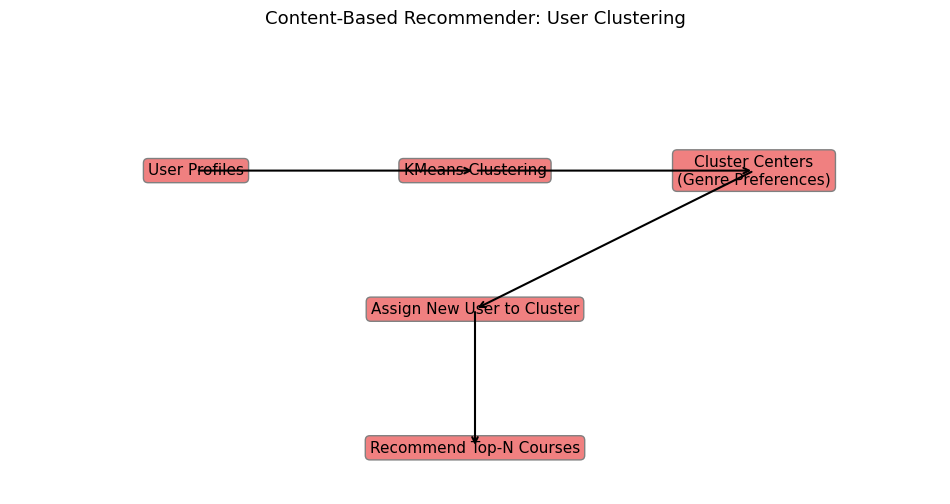

In [258]:
def draw_flowchart_clustering():
    fig, ax = plt.subplots(figsize=(12, 6))

    boxes = {
        "User Profiles": (0.2, 0.7),
        "KMeans Clustering": (0.5, 0.7),
        "Cluster Centers\n(Genre Preferences)": (0.8, 0.7),
        "Assign New User to Cluster": (0.5, 0.4),
        "Recommend Top-N Courses": (0.5, 0.1),
    }

    for text, (x, y) in boxes.items():
        ax.text(x, y, text, ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", edgecolor="gray"))

    arrows = [
        ("User Profiles", "KMeans Clustering"),
        ("KMeans Clustering", "Cluster Centers\n(Genre Preferences)"),
        ("Cluster Centers\n(Genre Preferences)", "Assign New User to Cluster"),
        ("Assign New User to Cluster", "Recommend Top-N Courses")
    ]

    for start, end in arrows:
        x1, y1 = boxes[start]
        x2, y2 = boxes[end]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color='black'))

    ax.axis('off')
    plt.title("Content-Based Recommender: User Clustering", fontsize=13)
    plt.show()

draw_flowchart_clustering()


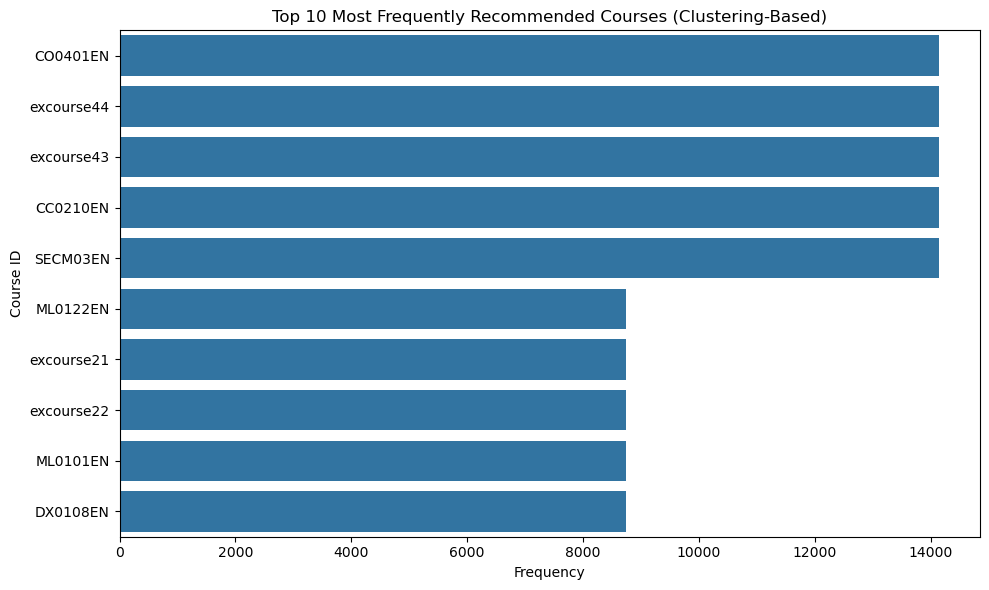

(4.683490162532078,
 [('CO0401EN', 14142),
  ('excourse44', 14142),
  ('excourse43', 14142),
  ('CC0210EN', 14142),
  ('SECM03EN', 14142),
  ('ML0122EN', 8742),
  ('excourse21', 8742),
  ('excourse22', 8742),
  ('ML0101EN', 8742),
  ('DX0108EN', 8742)])

In [327]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
profile_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv")
test_users_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv")
course_genres_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv")

# Prepare data
genre_cols = course_genres_df.columns[2:]
course_features = course_genres_df[genre_cols].values
user_profiles = profile_df[genre_cols].values

# Clustering users
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
user_clusters = kmeans.fit_predict(user_profiles)

# Calculate cluster centroids and similarities
cluster_centroids = kmeans.cluster_centers_
similarity_matrix = cosine_similarity(cluster_centroids, course_features)

# Recommend courses based on cluster centroids
top_n = 5
cluster_recommendations = {}
for cluster_id in range(n_clusters):
    top_indices = similarity_matrix[cluster_id].argsort()[::-1][:top_n]
    top_courses = course_genres_df.iloc[top_indices]['COURSE_ID'].tolist()
    cluster_recommendations[cluster_id] = top_courses

# Assign cluster-based recommendations to users
recommendations = {}
for idx, user_id in enumerate(profile_df['user']):
    cluster_id = user_clusters[idx]
    recommendations[user_id] = cluster_recommendations[cluster_id]

# Seen courses mapping
seen_courses = test_users_df.groupby('user')['item'].apply(set).to_dict()

# Evaluation: unseen recommendations
unseen_counts = []
for user_id, recs in recommendations.items():
    seen = seen_courses.get(user_id, set())
    new_courses = [course for course in recs if course not in seen]
    unseen_counts.append(len(new_courses))

avg_unseen = np.mean(unseen_counts)

# Top-10 most frequently recommended courses
all_recs = [course for recs in recommendations.values() for course in recs]
top_10_courses = Counter(all_recs).most_common(10)

# Plotting
unseen_df = pd.DataFrame({'Unseen Recommendations': unseen_counts})
top_courses_df = pd.DataFrame(top_10_courses, columns=["Course", "Count"])

# Bar plot for most frequently recommended courses
plt.figure(figsize=(10, 6))
sns.barplot(x="Count", y="Course", data=top_courses_df)
plt.title("Top 10 Most Frequently Recommended Courses (Clustering-Based)")
plt.xlabel("Frequency")
plt.ylabel("Course ID")
plt.tight_layout()
plt.show()

avg_unseen, top_10_courses


In [331]:
top_courses_df

,Course,Count
0,CO0401EN,14142
1,excourse44,14142
2,excourse43,14142
3,CC0210EN,14142
4,SECM03EN,14142
5,ML0122EN,8742
6,excourse21,8742
7,excourse22,8742
8,ML0101EN,8742
9,DX0108EN,8742


Results for different number of clusters:
n_clusters = 3: Average unseen recommendations = 4.76
n_clusters = 5: Average unseen recommendations = 4.80
n_clusters = 7: Average unseen recommendations = 4.48
n_clusters = 10: Average unseen recommendations = 4.68


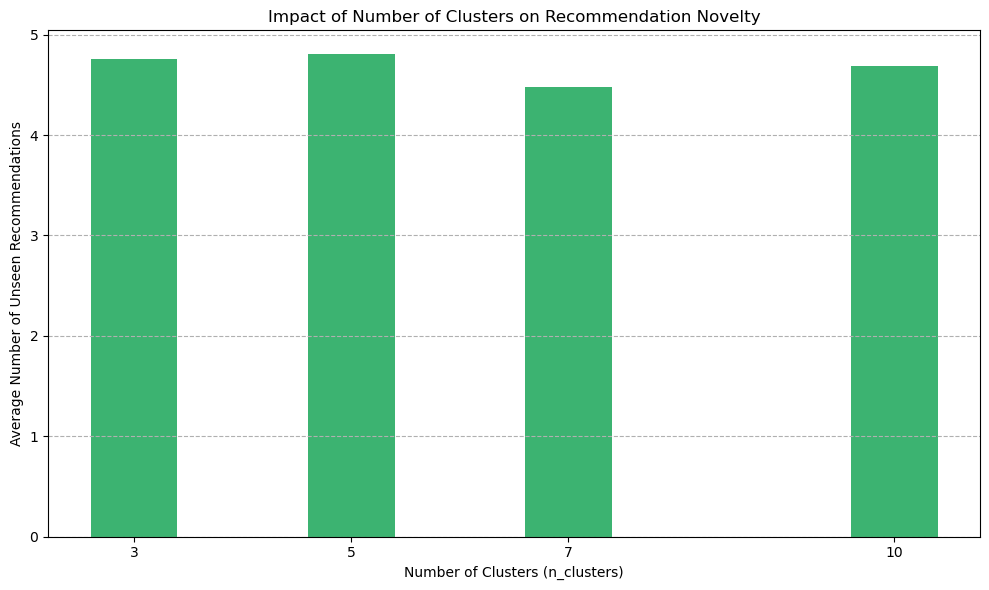

In [329]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (same as before)
profile_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv")
test_users_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv")
course_genres_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv")

# Prepare data (same as before)
genre_cols = course_genres_df.columns[2:]
course_features = course_genres_df[genre_cols].values
user_profiles = profile_df[genre_cols].values

# Hyperparameter: Number of clusters
n_clusters_values = [3, 5, 7, 10]
results = {}
top_n = 5  # Fixed top_n for this hyperparameter tuning

for n_clusters in n_clusters_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for future warning
    user_clusters = kmeans.fit_predict(user_profiles)
    cluster_centroids = kmeans.cluster_centers_
    similarity_matrix = cosine_similarity(cluster_centroids, course_features)
    cluster_recommendations = {}
    for cluster_id in range(n_clusters):
        top_indices = similarity_matrix[cluster_id].argsort()[::-1][:top_n]
        top_courses = course_genres_df.iloc[top_indices]['COURSE_ID'].tolist()
        cluster_recommendations[cluster_id] = top_courses

    recommendations = {}
    for idx, user_id in enumerate(profile_df['user']):
        cluster_id = user_clusters[idx]
        recommendations[user_id] = cluster_recommendations[cluster_id]

    seen_courses = test_users_df.groupby('user')['item'].apply(set).to_dict()
    unseen_counts = []
    for user_id, recs in recommendations.items():
        seen = seen_courses.get(user_id, set())
        new_courses = [course for course in recs if course not in seen]
        unseen_counts.append(len(new_courses))

    avg_unseen = np.mean(unseen_counts)
    results[n_clusters] = avg_unseen

print("Results for different number of clusters:")
for k, v in results.items():
    print(f"n_clusters = {k}: Average unseen recommendations = {v:.2f}")

# Plotting the results for number of clusters
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='mediumseagreen')
plt.xlabel("Number of Clusters (n_clusters)")
plt.ylabel("Average Number of Unseen Recommendations")
plt.title("Impact of Number of Clusters on Recommendation Novelty")
plt.xticks(list(results.keys()))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# To similarly analyze the impact of 'top_n', you would fix 'n_clusters'
# and vary 'top_n' in a similar loop structure.

Computing the msd similarity matrix...
Done computing similarity matrix.


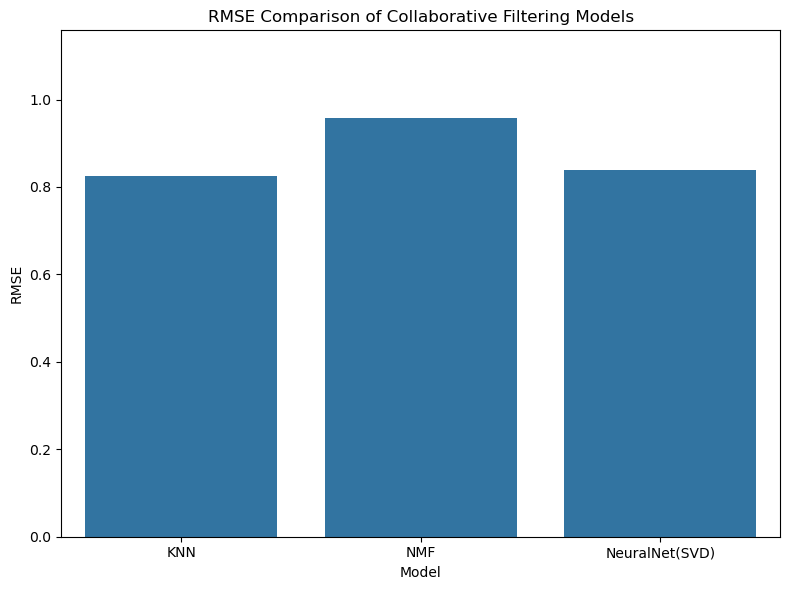

            Model      RMSE
0             KNN  0.824059
1             NMF  0.958367
2  NeuralNet(SVD)  0.839940


In [337]:
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, KNNBasic, NMF, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Load the datasets
profile_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv")
test_users_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv")
course_genres_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv")

# Prepare data for surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(test_users_df[['user', 'item', 'rating']], reader)

# Split data into train and test set using surprise's train_test_split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# 1. KNN-based Collaborative Filtering
knn_model = KNNBasic(sim_options={'user_based': True})
knn_model.fit(trainset)
predictions_knn = knn_model.test(testset)
rmse_knn = accuracy.rmse(predictions_knn, verbose=False)

# 2. NMF-based Collaborative Filtering
nmf_model = NMF()
nmf_model.fit(trainset)
predictions_nmf = nmf_model.test(testset)
rmse_nmf = accuracy.rmse(predictions_nmf, verbose=False)

# 3. SVD-based (as Neural Network-like Latent Embedding) Collaborative Filtering
svd_model = SVD()
svd_model.fit(trainset)
predictions_svd = svd_model.test(testset)
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)

# Plotting RMSE results
rmse_results = pd.DataFrame({
    'Model': ['KNN', 'NMF', 'NeuralNet(SVD)'],
    'RMSE': [rmse_knn, rmse_nmf, rmse_svd]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='RMSE', data=rmse_results)
plt.title("RMSE Comparison of Collaborative Filtering Models")
plt.ylabel("RMSE")
plt.ylim(0, max(rmse_results['RMSE']) + 0.2)
plt.tight_layout()
plt.show()

print(rmse_results)

In [391]:
profile_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv")
test_users_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv")
course_genres_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv")
test_users_df

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3
...,...,...,...
233301,1540125,DS0101EN,5
233302,1250651,PY0101EN,5
233303,1003832,CB0105ENv1,3
233304,922065,BD0141EN,4


In [403]:
course_genres_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   COURSE_ID        307 non-null    object
 1   TITLE            307 non-null    object
 2   Database         307 non-null    int64 
 3   Python           307 non-null    int64 
 4   CloudComputing   307 non-null    int64 
 5   DataAnalysis     307 non-null    int64 
 6   Containers       307 non-null    int64 
 7   MachineLearning  307 non-null    int64 
 8   ComputerVision   307 non-null    int64 
 9   DataScience      307 non-null    int64 
 10  BigData          307 non-null    int64 
 11  Chatbot          307 non-null    int64 
 12  R                307 non-null    int64 
 13  BackendDev       307 non-null    int64 
 14  FrontendDev      307 non-null    int64 
 15  Blockchain       307 non-null    int64 
dtypes: int64(14), object(2)
memory usage: 38.5+ KB


Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 0.8241
RMSE: 0.9602
RMSE: 0.8391


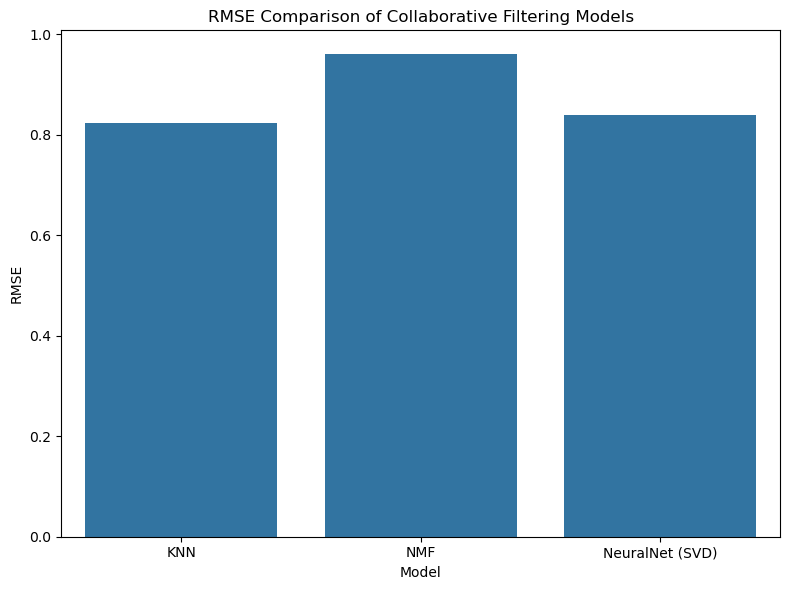

In [341]:
# Install surprise if not already installed
# !pip install scikit-surprise

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise.model_selection import train_test_split
from surprise import Dataset, Reader, KNNBasic, NMF, SVD, accuracy

# Load dataset
ratings = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv")

# Prepare data for Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user', 'item', 'rating']], reader)

# Train-test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# KNN Model
knn = KNNBasic(sim_options={'user_based': True})
knn.fit(trainset)
pred_knn = knn.test(testset)
rmse_knn = accuracy.rmse(pred_knn)

# NMF Model
nmf = NMF()
nmf.fit(trainset)
pred_nmf = nmf.test(testset)
rmse_nmf = accuracy.rmse(pred_nmf)

# Neural Network Embedding (SVD)
svd = SVD()
svd.fit(trainset)
pred_svd = svd.test(testset)
rmse_svd = accuracy.rmse(pred_svd)

# Compare RMSE
rmse_df = pd.DataFrame({
    'Model': ['KNN', 'NMF', 'NeuralNet (SVD)'],
    'RMSE': [rmse_knn, rmse_nmf, rmse_svd]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='RMSE', data=rmse_df)
plt.title("RMSE Comparison of Collaborative Filtering Models")
plt.tight_layout()
plt.show()


In [355]:
from graphviz import Digraph
import os
import platform
import subprocess

def create_flowchart(model_name):
    """
    Creates a flowchart visualizing the collaborative filtering process using Graphviz.

    Args:
        model_name (str): The name of the collaborative filtering model (e.g., 'KNN', 'NMF', 'SVD').

    Returns:
        graphviz.Digraph: A Graphviz Digraph object representing the flowchart.  Returns None on error.
    """
    try:
        dot = Digraph()
        dot.attr(rankdir='LR')  # Left-to-right layout

        # Define nodes
        dot.node('A', 'Raw Ratings Dataset', shape='box')
        dot.node('B', f'{model_name} Collaborative Filtering', shape='box')
        dot.node('C', 'Train-Test Split', shape='box')
        dot.node('D', 'Model Training', shape='box')
        dot.node('E', 'Generate Predictions', shape='box')
        dot.node('F', 'Evaluate with RMSE', shape='box')

        # Define edges (connections between nodes)
        dot.edge('A', 'C')
        dot.edge('C', 'B')
        dot.edge('B', 'D')
        dot.edge('D', 'E')
        dot.edge('E', 'F')

        return dot
    except Exception as e:
        print(f"Error creating flowchart: {e}")
        print("Please ensure Graphviz is installed and its 'bin' directory is added to your system's PATH.")
        return None

def check_graphviz_installed():
    """
    Checks if Graphviz is installed and the 'dot' executable is in the system's PATH.

    Returns:
        bool: True if Graphviz is found, False otherwise.
    """
    try:
        # Use subprocess.run to execute the 'dot' command
        result = subprocess.run(['dot', '-V'], capture_output=True, check=True)
        # If the command runs successfully, Graphviz is likely installed
        return True
    except (FileNotFoundError, subprocess.CalledProcessError):
        return False

def get_os_info():
    """
    Gets the operating system name and version.

    Returns:
        str: A string containing the OS information.
    """
    os_name = platform.system()
    os_version = platform.version()
    return f"{os_name} {os_version}"

def display_flowchart(model_name):
    """
    Creates and displays the flowchart for a given collaborative filtering model.

    Args:
        model_name (str): The name of the model ('KNN', 'NMF', or 'SVD').
    """
    if not check_graphviz_installed():
        os_info = get_os_info()
        print(f"Graphviz is not properly installed or the 'dot' executable is not in your system's PATH.")
        print(f"Please follow these steps to install Graphviz for your operating system ({os_info}):")
        if "Windows" in os_info:
            print("1.  Download the Graphviz installer from https://graphviz.org/download/.")
            print("2.  Install Graphviz, making sure to add it to your system's PATH during installation.")
            print("3.  Open a new command prompt or terminal and type 'dot -V' to verify the installation.")
        elif "Linux" in os_info:
            print("1.  Use your distribution's package manager to install Graphviz (e.g., 'sudo apt-get install graphviz' on Ubuntu/Debian, 'sudo yum install graphviz' on CentOS/RHEL, 'sudo pacman -S graphviz' on Arch Linux).")
            print("2.  Open a new terminal and type 'dot -V' to verify the installation.")
        elif "Darwin" in os_info:  # macOS
            print("1.  You can install Graphviz using Homebrew: 'brew install graphviz'.  If you don't have Homebrew, install it from https://brew.sh/ first.")
            print("2.  Open a new terminal and type 'dot -V' to verify the installation.")
        else:
            print("1.  Visit the Graphviz website (https://graphviz.org/download/) and follow the installation instructions for your operating system.")
        return  # IMPORTANT: Exit if Graphviz is not installed

    dot = create_flowchart(model_name)
    if dot:
        try:
            # Attempt to render the graph to a file (e.g., PNG) and display it
            filepath = dot.render(filename=f"{model_name}_flowchart", format='png', cleanup=True)
            print(f"Flowchart saved to {filepath}")
            # You might need to use a library like IPython.display to show the image in a notebook
            # For example:
            # from IPython.display import Image, display
            # display(Image(filename=filepath))

        except Exception as e:
            print(f"Error rendering/displaying flowchart: {e}")
            print("Please ensure Graphviz is correctly installed and configured.")

if __name__ == "__main__":
    # Example usage:
    model_name = 'KNN'  # You can change this to 'NMF' or 'SVD'
    display_flowchart(model_name)
    model_name = 'NMF'
    display_flowchart(model_name)
    model_name = 'SVD'
    display_flowchart(model_name)


Graphviz is not properly installed or the 'dot' executable is not in your system's PATH.
Please follow these steps to install Graphviz for your operating system (Darwin Darwin Kernel Version 24.4.0: Fri Apr 11 18:34:14 PDT 2025; root:xnu-11417.101.15~117/RELEASE_ARM64_T8122):
1.  You can install Graphviz using Homebrew: 'brew install graphviz'.  If you don't have Homebrew, install it from https://brew.sh/ first.
2.  Open a new terminal and type 'dot -V' to verify the installation.
Graphviz is not properly installed or the 'dot' executable is not in your system's PATH.
Please follow these steps to install Graphviz for your operating system (Darwin Darwin Kernel Version 24.4.0: Fri Apr 11 18:34:14 PDT 2025; root:xnu-11417.101.15~117/RELEASE_ARM64_T8122):
1.  You can install Graphviz using Homebrew: 'brew install graphviz'.  If you don't have Homebrew, install it from https://brew.sh/ first.
2.  Open a new terminal and type 'dot -V' to verify the installation.
Graphviz is not properly ins

In [376]:
display_flowchart('SVD')

Flowchart saved to SVD_flowchart.png


In [ ]:
pd.read_csv('data/